In [5]:
#Import Required Libraries
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
data = { 
"ModelID": [ 
"M001","M002","M003","M004","M005","M006","M007","M008","M009","M010", 
"M011","M012","M013","M014","M015","M016","M017","M018","M019","M020", 
"M021","M022","M023","M024","M025","M026","M027","M028","M029","M030", 
"M031","M032","M033","M034","M035","M036","M037","M038","M039","M040", 
        "M041","M042","M043","M044","M045","M046","M047","M048","M049","M050" 
    ], 
 
    "Algorithm": [ 
        "RandomForest","XGBoost","CNN","LSTM","SVM", 
        "DecisionTree","Transformer","RandomForest","CNN","XGBoost", 
        "LSTM","Transformer","SVM","RandomForest","CNN", 
        "XGBoost","DecisionTree","LSTM","Transformer","CNN", 
        "RandomForest","XGBoost","CNN","Transformer","SVM", 
        "DecisionTree","RandomForest","CNN","LSTM","Transformer", 
        "RandomForest","CNN","XGBoost","LSTM","SVM", 
        "Transformer","DecisionTree","RandomForest","CNN","XGBoost", 
        "LSTM","Transformer","CNN","RandomForest","SVM", 
        "DecisionTree","XGBoost","Transformer","CNN","RandomForest" 
    ], 
 
    "TrainingSamples": [ 
        120000,95000,150000,210000,85000, 
        60000,300000,140000,175000,98000, 
        225000,315000,90000,132000,182000, 
        110000,72000,250000,330000,165000, 
        128000,103000,194000,280000,88000, 
        64000,145000,180000,240000,350000, 
        150000,190000,100000,260000,92000, 
        340000,70000,155000,205000,115000, 
        270000,360000,170000,149000,87000, 
        62000,108000,320000,185000,142000 
    ], 
 
    "Accuracy": [ 
        96.2,91.5,98.1,94.6,88.2, 
        84.5,99.1,95.8,97.3,90.8, 
        95.2,99.4,89.3,94.8,96.7, 
        92.4,83.9,95.9,99.5,97.0, 
        95.1,91.2,97.8,99.0,87.6, 
        84.2,95.7,97.5,96.0,99.2, 
        95.5,97.2,91.0,95.8,88.5, 
        99.1,83.7,95.6,97.4,92.1, 
        95.9,99.6,96.8,94.9,88.8, 
        84.0,91.8,99.3,97.1,95.3 
    ], 
 
    "InferenceLatency": [ 
        45,80,120,95,40, 
        30,210,55,130,85, 
        110,260,42,60,125, 
        78,28,108,240,135, 
        58,82,118,225,38, 
        25,52,132,105,250, 
        63,128,76,115,41, 
        235,26,50,138,74, 
        112,255,127,57,39, 
        27,79,220,129,56 
    ], 
 
    "DataDrift": [ 
        2,8,3,6,18, 
        25,1,4,5,10, 
        7,0,20,6,3, 
        9,27,5,1,4, 
        6,8,2,1,19, 
        26,5,4,6,0, 
        3,2,9,5,18, 
        1,28,4,5,10, 
        6,0,4,5,21, 
        25,9,1,3,4 
    ], 
 
    "CPUUsage": [ 
        42,60,75,68,38, 
        30,91,50,72,61, 
        69,95,41,52,76, 
        59,28,67,94,74, 
        53,62,73,90,39, 
        26,49,71,66,96, 
        54,70,63,68,40, 
        92,25,48,74,60, 
        69,97,77,51,37, 
        29,58,93,72,47 
    ], 
 
    "PredictionConfidence": [ 
        0.98,0.91,0.99,0.95,0.84, 
        0.80,0.99,0.97,0.98,0.90, 
        0.96,0.99,0.85,0.95,0.98, 
        0.92,0.79,0.96,0.99,0.98, 
        0.95,0.91,0.98,0.99,0.83, 
        0.81,0.96,0.97,0.95,0.99, 
        0.96,0.98,0.90,0.96,0.84, 
        0.99,0.78,0.95,0.98,0.91, 
        0.96,0.99,0.97,0.95,0.85, 
        0.80,0.92,0.99,0.98,0.96 
    ], 
 
    "FailureRisk": [ 
        0,0,0,0,1, 
        1,0,0,0,0, 
        0,0,1,0,0, 
        0,1,0,0,0, 
        0,0,0,0,1, 
        1,0,0,0,0, 
        0,0,0,0,1, 
        0,1,0,0,0, 
        0,0,0,0,1, 
        1,0,0,0,0 
    ] 
}

In [7]:
df = pd.DataFrame(data)

In [7]:
#1 Convert all numerical columns into NumPy arrays
training_samples = df["TrainingSamples"].to_numpy()
accuracy = df["Accuracy"].to_numpy()
latency = df["InferenceLatency"].to_numpy()
data_drift = df["DataDrift"].to_numpy()
cpu_usage = df["CPUUsage"].to_numpy()
prediction_confidence = df["PredictionConfidence"].to_numpy()
failure_risk = df["FailureRisk"].to_numpy()

In [8]:
#2 Display shape, size, dimensions and datatype
arrays = {
    "TrainingSamples": training_samples,
    "Accuracy": accuracy,
    "InferenceLatency": latency,
    "DataDrift": data_drift,
    "CPUUsage": cpu_usage,
    "PredictionConfidence": prediction_confidence,
    "FailureRisk": failure_risk
}

for name, array in arrays.items():
    print(f"\n{name}")
    print("Shape :", array.shape)
    print("Size :", array.size)
    print("Dimensions :", array.ndim)
    print("Data Type :", array.dtype)


TrainingSamples
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : int64

Accuracy
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : float64

InferenceLatency
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : int64

DataDrift
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : int64

CPUUsage
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : int64

PredictionConfidence
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : float64

FailureRisk
Shape : (50,)
Size : 50
Dimensions : 1
Data Type : int64


In [10]:
#Mean, Median, Variance and Standard Deviation of Accuracy
print("Mean :", np.mean(accuracy))
print("Median :", np.median(accuracy))
print("Variance :", np.var(accuracy))
print("Standard Deviation :", np.std(accuracy))

Mean : 94.058
Median : 95.65
Variance : 21.235635999999996
Standard Deviation : 4.608213970726619


In [11]:
# Maximum and Minimum Inference Latency
print("Maximum Latency :", np.max(latency))
print("Minimum Latency :", np.min(latency))

Maximum Latency : 260
Minimum Latency : 25


In [12]:
# Models having CPU Usage greater than 90%
high_cpu = df["CPUUsage"].to_numpy() > 90

print(df.loc[high_cpu, ["ModelID", "CPUUsage"]])

   ModelID  CPUUsage
6     M007        91
11    M012        95
18    M019        94
29    M030        96
35    M036        92
41    M042        97
47    M048        93


In [13]:
#Models having Data Drift greater than 20
high_drift = df["DataDrift"].to_numpy() > 20
print(df.loc[high_drift, ["ModelID", "DataDrift"]])

   ModelID  DataDrift
5     M006         25
16    M017         27
25    M026         26
36    M037         28
44    M045         21
45    M046         25


In [14]:
# Normalize TrainingSamples using Min-Max Normalization
normalized_training = (training_samples - np.min(training_samples)) / (
    np.max(training_samples) - np.min(training_samples)
)
print(normalized_training)

[0.2        0.11666667 0.3        0.5        0.08333333 0.
 0.8        0.26666667 0.38333333 0.12666667 0.55       0.85
 0.1        0.24       0.40666667 0.16666667 0.04       0.63333333
 0.9        0.35       0.22666667 0.14333333 0.44666667 0.73333333
 0.09333333 0.01333333 0.28333333 0.4        0.6        0.96666667
 0.3        0.43333333 0.13333333 0.66666667 0.10666667 0.93333333
 0.03333333 0.31666667 0.48333333 0.18333333 0.7        1.
 0.36666667 0.29666667 0.09       0.00666667 0.16       0.86666667
 0.41666667 0.27333333]


In [ ]:
# AI Health Score Formula: Health Score = Accuracy + PredictionConfidence × 100 − DataDrift
health_score = accuracy + (prediction_confidence * 100) - data_drift
print(health_score)

[192.2 174.5 194.1 183.6 154.2 139.5 197.1 188.8 190.3 170.8 184.2 198.4
 154.3 183.8 191.7 175.4 135.9 186.9 197.5 191.  184.1 174.2 193.8 197.
 151.6 139.2 186.7 190.5 185.  198.2 188.5 193.2 172.  186.8 154.5 197.1
 133.7 186.6 190.4 173.1 185.9 198.6 189.8 184.9 152.8 139.  174.8 197.3
 192.1 187.3]


In [16]:
# Convert the dataset into a Pandas DataFrame
df = pd.DataFrame(data)

In [17]:
# Display the first 10 and last 10 records
print("First 10 Records")
print(df.head(10))
print("\nLast 10 Records")
print(df.tail(10))

First 10 Records
  ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
0    M001  RandomForest           120000      96.2                45   
1    M002       XGBoost            95000      91.5                80   
2    M003           CNN           150000      98.1               120   
3    M004          LSTM           210000      94.6                95   
4    M005           SVM            85000      88.2                40   
5    M006  DecisionTree            60000      84.5                30   
6    M007   Transformer           300000      99.1               210   
7    M008  RandomForest           140000      95.8                55   
8    M009           CNN           175000      97.3               130   
9    M010       XGBoost            98000      90.8                85   

   DataDrift  CPUUsage  PredictionConfidence  FailureRisk  
0          2        42                  0.98            0  
1          8        60                  0.91            0  
2         

In [18]:
# Display dataset information using info()
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ModelID               50 non-null     str    
 1   Algorithm             50 non-null     str    
 2   TrainingSamples       50 non-null     int64  
 3   Accuracy              50 non-null     float64
 4   InferenceLatency      50 non-null     int64  
 5   DataDrift             50 non-null     int64  
 6   CPUUsage              50 non-null     int64  
 7   PredictionConfidence  50 non-null     float64
 8   FailureRisk           50 non-null     int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 3.6 KB
None


In [19]:
# Generate descriptive statistics
print(df.describe())

       TrainingSamples   Accuracy  InferenceLatency  DataDrift   CPUUsage  \
count        50.000000  50.000000         50.000000   50.00000  50.000000   
mean     172120.000000  94.058000        104.160000    8.08000  61.820000   
std       85728.722594   4.654999         67.930144    7.98427  20.029254   
min       60000.000000  83.700000         25.000000    0.00000  25.000000   
25%      100750.000000  91.275000         52.750000    3.00000  48.250000   
50%      150000.000000  95.650000         83.500000    5.00000  62.500000   
75%      221250.000000  97.275000        128.750000    9.00000  73.750000   
max      360000.000000  99.600000        260.000000   28.00000  97.000000   

       PredictionConfidence  FailureRisk  
count             50.000000    50.000000  
mean               0.932800     0.200000  
std                0.063569     0.404061  
min                0.780000     0.000000  
25%                0.910000     0.000000  
50%                0.960000     0.000000  
75%  

In [22]:
# Check for missing values
print(df.isnull().sum())

ModelID                 0
Algorithm               0
TrainingSamples         0
Accuracy                0
InferenceLatency        0
DataDrift               0
CPUUsage                0
PredictionConfidence    0
FailureRisk             0
dtype: int64


In [21]:
# Check for duplicate records
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


In [23]:
# Display the number of models for each algorithm
algorithm_count = df["Algorithm"].value_counts()

print(algorithm_count)

Algorithm
CNN             10
RandomForest     9
Transformer      8
XGBoost          7
LSTM             6
SVM              5
DecisionTree     5
Name: count, dtype: int64


In [ ]:
# Average accuracy for each algorithm
average_accuracy = df.groupby("Algorithm")["Accuracy"].mean()

print(average_accuracy)


In [24]:
# Top 10 models with highest Prediction Confidence
top_models = df.sort_values(
    by="PredictionConfidence",
    ascending=False
).head(10)

print(top_models[["ModelID", "Algorithm", "PredictionConfidence"]])

   ModelID     Algorithm  PredictionConfidence
6     M007   Transformer                  0.99
2     M003           CNN                  0.99
11    M012   Transformer                  0.99
29    M030   Transformer                  0.99
47    M048   Transformer                  0.99
41    M042   Transformer                  0.99
35    M036   Transformer                  0.99
18    M019   Transformer                  0.99
23    M024   Transformer                  0.99
0     M001  RandomForest                  0.98


In [25]:
# Sort dataset by InferenceLatency (Descending)
sorted_latency = df.sort_values(
    by="InferenceLatency",
    ascending=False
)

print(sorted_latency)

   ModelID     Algorithm  TrainingSamples  Accuracy  InferenceLatency  \
11    M012   Transformer           315000      99.4               260   
41    M042   Transformer           360000      99.6               255   
29    M030   Transformer           350000      99.2               250   
18    M019   Transformer           330000      99.5               240   
35    M036   Transformer           340000      99.1               235   
23    M024   Transformer           280000      99.0               225   
47    M048   Transformer           320000      99.3               220   
6     M007   Transformer           300000      99.1               210   
38    M039           CNN           205000      97.4               138   
19    M020           CNN           165000      97.0               135   
27    M028           CNN           180000      97.5               132   
8     M009           CNN           175000      97.3               130   
48    M049           CNN           185000      97.1

In [26]:
# Create HealthStatus column
health_score = (
    df["Accuracy"] +
    (df["PredictionConfidence"] * 100) -
    df["DataDrift"]
)

status = []

for score in health_score:
    if score >= 190:
        status.append("Healthy")
    elif score >= 170:
        status.append("Moderate")
    else:
        status.append("Critical")

df["HealthStatus"] = status

print(df[["ModelID", "HealthStatus"]])

   ModelID HealthStatus
0     M001      Healthy
1     M002     Moderate
2     M003      Healthy
3     M004     Moderate
4     M005     Critical
5     M006     Critical
6     M007      Healthy
7     M008     Moderate
8     M009      Healthy
9     M010     Moderate
10    M011     Moderate
11    M012      Healthy
12    M013     Critical
13    M014     Moderate
14    M015      Healthy
15    M016     Moderate
16    M017     Critical
17    M018     Moderate
18    M019      Healthy
19    M020      Healthy
20    M021     Moderate
21    M022     Moderate
22    M023      Healthy
23    M024      Healthy
24    M025     Critical
25    M026     Critical
26    M027     Moderate
27    M028      Healthy
28    M029     Moderate
29    M030      Healthy
30    M031     Moderate
31    M032      Healthy
32    M033     Moderate
33    M034     Moderate
34    M035     Critical
35    M036      Healthy
36    M037     Critical
37    M038     Moderate
38    M039      Healthy
39    M040     Moderate
40    M041     M

In [27]:
# Export the processed dataset
df.to_csv("AI_Model_Health_Report.csv", index=False)

print("Dataset exported successfully.")

Dataset exported successfully.


In [28]:
# Calculate the Correlation Matrix
correlation = df.corr(numeric_only=True)

print(correlation)

                      TrainingSamples  Accuracy  InferenceLatency  DataDrift  \
TrainingSamples              1.000000  0.806547          0.916954  -0.718419   
Accuracy                     0.806547  1.000000          0.762794  -0.968185   
InferenceLatency             0.916954  0.762794          1.000000  -0.681309   
DataDrift                   -0.718419 -0.968185         -0.681309   1.000000   
CPUUsage                     0.883132  0.866731          0.946370  -0.823795   
PredictionConfidence         0.738309  0.985874          0.691598  -0.983163   
FailureRisk                 -0.560406 -0.845013         -0.524630   0.924845   

                      CPUUsage  PredictionConfidence  FailureRisk  
TrainingSamples       0.883132              0.738309    -0.560406  
Accuracy              0.866731              0.985874    -0.845013  
InferenceLatency      0.946370              0.691598    -0.524630  
DataDrift            -0.823795             -0.983163     0.924845  
CPUUsage           

In [29]:
# Identify the feature most correlated with FailureRisk
failure_corr = correlation["FailureRisk"].sort_values(ascending=False)

print(failure_corr)

FailureRisk             1.000000
DataDrift               0.924845
InferenceLatency       -0.524630
TrainingSamples        -0.560406
CPUUsage               -0.719187
Accuracy               -0.845013
PredictionConfidence   -0.904182
Name: FailureRisk, dtype: float64


In [30]:
# Compare average latency for healthy and failed models
latency_comparison = df.groupby("FailureRisk")["InferenceLatency"].mean()

print(latency_comparison)

FailureRisk
0    121.8
1     33.6
Name: InferenceLatency, dtype: float64


In [31]:
# Average CPU usage for each algorithm
average_cpu = df.groupby("Algorithm")["CPUUsage"].mean()

print(average_cpu)

Algorithm
CNN             73.400000
DecisionTree    27.600000
LSTM            67.833333
RandomForest    49.555556
SVM             39.000000
Transformer     93.500000
XGBoost         60.428571
Name: CPUUsage, dtype: float64


In [32]:
# Average prediction confidence for healthy and failed models
confidence = df.groupby("FailureRisk")["PredictionConfidence"].mean()

print(confidence)

FailureRisk
0    0.96125
1    0.81900
Name: PredictionConfidence, dtype: float64


In [33]:
# Models with Accuracy >95% but FailureRisk = 1
high_accuracy_failure = df[
    (df["Accuracy"] > 95) &
    (df["FailureRisk"] == 1)
]

print(high_accuracy_failure[
    ["ModelID",
     "Algorithm",
     "Accuracy",
     "FailureRisk"]
])

Empty DataFrame
Columns: [ModelID, Algorithm, Accuracy, FailureRisk]
Index: []


In [34]:
# Average Data Drift for every algorithm
average_drift = df.groupby("Algorithm")["DataDrift"].mean()

print(average_drift)

Algorithm
CNN              3.500000
DecisionTree    26.200000
LSTM             5.833333
RandomForest     4.333333
SVM             19.200000
Transformer      0.625000
XGBoost          9.000000
Name: DataDrift, dtype: float64


In [35]:
# Top 5 Healthiest AI Models
df["HealthScore"] = (
    df["Accuracy"] +
    df["PredictionConfidence"] * 100 -
    df["DataDrift"]
)

top5_healthy = df.sort_values(
    by="HealthScore",
    ascending=False
).head(5)

print(top5_healthy[
    ["ModelID",
     "Algorithm",
     "HealthScore"]
])

   ModelID    Algorithm  HealthScore
41    M042  Transformer        198.6
11    M012  Transformer        198.4
29    M030  Transformer        198.2
18    M019  Transformer        197.5
47    M048  Transformer        197.3


In [36]:
# Top 5 Highest-Risk Models
top5_risk = df.sort_values(
    by="HealthScore"
).head(5)

print(top5_risk[
    ["ModelID",
     "Algorithm",
     "HealthScore"]
])

   ModelID     Algorithm  HealthScore
36    M037  DecisionTree        133.7
16    M017  DecisionTree        135.9
45    M046  DecisionTree        139.0
25    M026  DecisionTree        139.2
5     M006  DecisionTree        139.5


In [ ]:
# Five Observations
# Observations

# 1. Models with high CPU usage usually have higher failure risk.

# 2. Increased data drift reduces the overall health score.

# 3. Models with higher prediction confidence are generally more reliable.

# 4. High accuracy alone does not guarantee a low failure risk.

# 5. Transformer and CNN models generally achieve higher health scores than some other algorithms.

Note: you may need to restart the kernel to use updated packages.


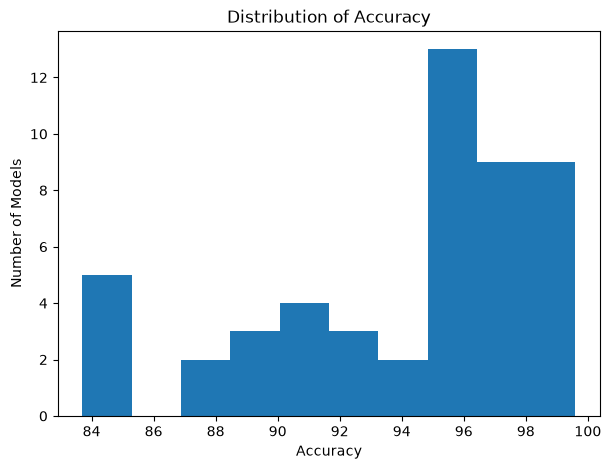

In [8]:
# Histogram of Accuracy
import matplotlib.pyplot as plt
%pip install matplotlib
plt.figure(figsize=(7,5))
plt.hist(df["Accuracy"], bins=10)
plt.title("Distribution of Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Number of Models")
plt.show()

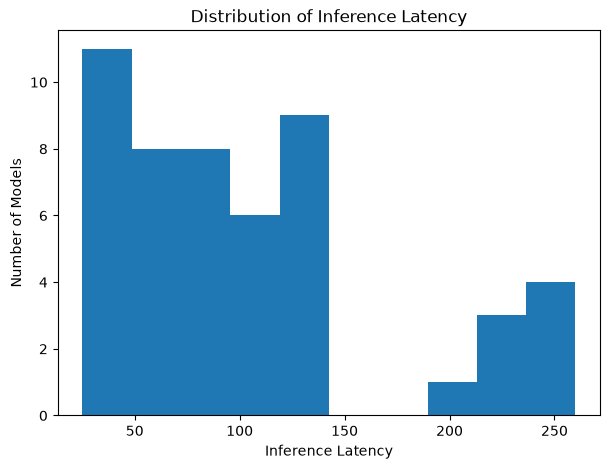

In [9]:
# Histogram of Inference Latency
plt.figure(figsize=(7,5))
plt.hist(df["InferenceLatency"], bins=10)
plt.title("Distribution of Inference Latency")
plt.xlabel("Inference Latency")
plt.ylabel("Number of Models")
plt.show()

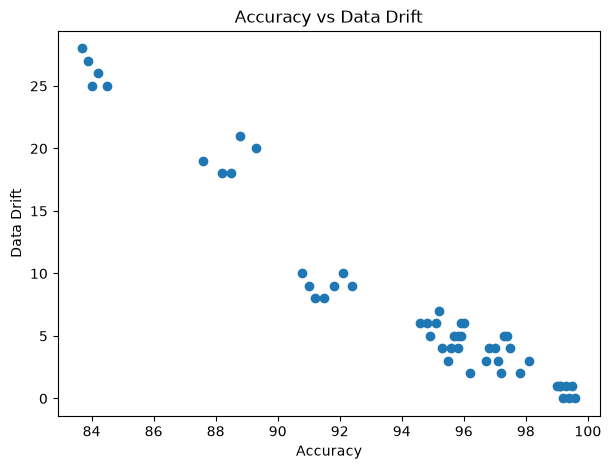

In [10]:
# Scatter Plot of Accuracy vs Data Drift
plt.figure(figsize=(7,5))
plt.scatter(df["Accuracy"], df["DataDrift"])

plt.title("Accuracy vs Data Drift")
plt.xlabel("Accuracy")
plt.ylabel("Data Drift")

plt.show()

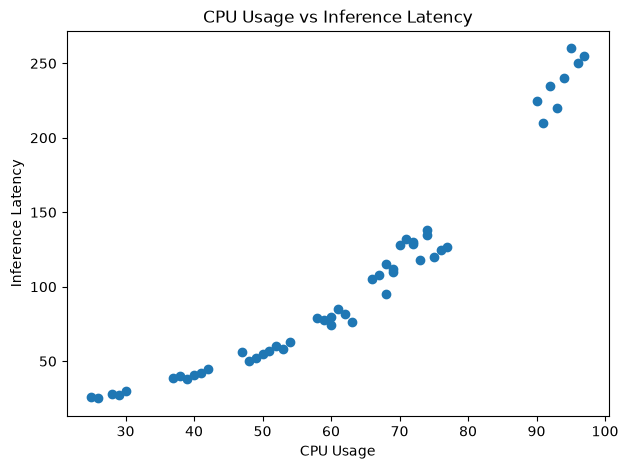

In [11]:
# Scatter Plot of CPU Usage vs Inference Latency
plt.figure(figsize=(7,5))
plt.scatter(df["CPUUsage"], df["InferenceLatency"])

plt.title("CPU Usage vs Inference Latency")
plt.xlabel("CPU Usage")
plt.ylabel("Inference Latency")

plt.show()

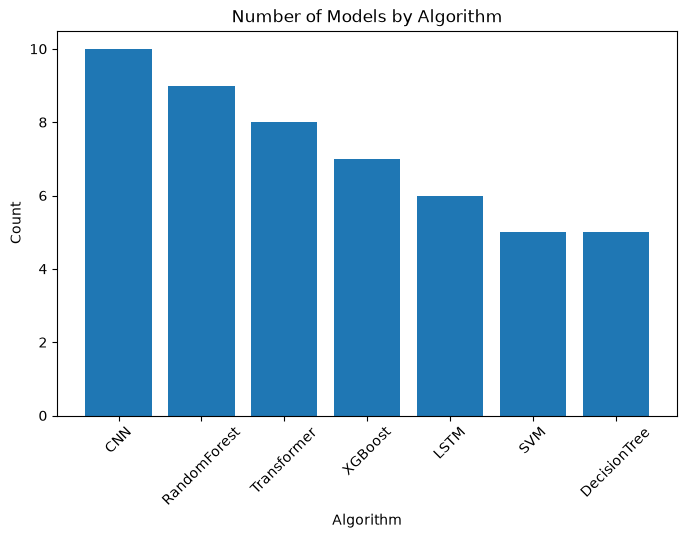

In [12]:
# Bar Chart of Algorithms
algorithm_count = df["Algorithm"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(algorithm_count.index, algorithm_count.values)

plt.title("Number of Models by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

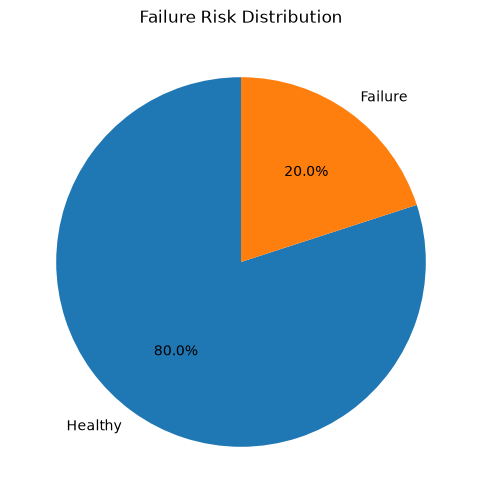

In [13]:
# Pie Chart of Failure Risk
failure = df["FailureRisk"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    failure.values,
    labels=["Healthy", "Failure"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Failure Risk Distribution")

plt.show()

In [ ]:
# Encode Algorithm Column

encoder = LabelEncoder()

df["Algorithm"] = encoder.fit_transform(df["Algorithm"])

In [ ]:
# Train-Test Split (80:20)
#Features
X = df.drop(["ModelID", "FailureRisk", "HealthStatus"], axis=1)

In [17]:
# Target
y = df["FailureRisk"]

In [ ]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
# Train Random Forest Classifier
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

In [ ]:
# Predictions
y_pred = model.predict(X_test)

In [ ]:
# Accuracy Score
print("Accuracy Score")

print(accuracy_score(y_test, y_pred))

In [ ]:
# Confusion Matrix
print("Confusion Matrix")

print(confusion_matrix(y_test, y_pred))

In [ ]:
# Classification Report
print("Classification Report")

print(classification_report(y_test, y_pred))


In [22]:
#Predict Failure Risk for New Models
new_models = pd.DataFrame({

    "Algorithm":[
        "Transformer",
        "RandomForest",
        "CNN"
    ],

    "TrainingSamples":[
        275000,
        135000,
        190000
    ],

    "Accuracy":[
        98.4,
        93.8,
        96.5
    ],

    "InferenceLatency":[
        215,
        68,
        145
    ],

    "DataDrift":[
        4,
        12,
        6
    ],

    "CPUUsage":[
        88,
        54,
        72
    ],

    "PredictionConfidence":[
        0.98,
        0.92,
        0.97
    ]
})

In [ ]:
prediction = model.predict(new_models)

new_models["PredictedFailureRisk"] = prediction

print(new_models)

In [ ]:
for index, row in new_models.iterrows():

    print("\nModel", index + 1)

    if row["PredictedFailureRisk"] == 0:
        print("Recommendation : Safe to deploy.")
    else:
        print("Recommendation : Monitor the model before deployment.")